<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# **Embedding Model Comparison with PCA or t-SNE**

Estimated time needed: **40** minutes


## Overview

In this lab, you will benchmark multiple embedding approaches on the same corpus and evaluate them from both a retrieval and visualization perspective. This mirrors real Data Engineering workflows where teams must justify model choice using evidence, not intuition.

You will build a compact embedding evaluation pipeline that:

- creates multiple embedding spaces from one dataset,
- measures retrieval quality with ranking metrics, and
- visualizes geometric structure using both PCA and t-SNE.

Real-world use cases include semantic customer ticket routing, product similarity search, fraud pattern retrieval, and knowledge base question matching, where embedding quality directly impacts relevance, latency, and infrastructure cost.


<h2 id="Table-of-Contents">Table of Contents</h2>

<div class="alert alert-block alert-info" style="margin-top: 20px">
<ol>
    <li><a href="#Overview">Overview</a></li>
    <li><a href="#Materials-and-Methods">Materials and Methods</a></li>
    <li><a href="#Dataset-Information">Dataset Information</a></li>
    <li><a href="#Objectives">Objectives</a></li>
    <li><a href="#Setup-and-Data-Checks">Setup and Data Checks</a></li>
    <li><a href="#Embedding-Pipeline">Embedding Pipeline</a></li>
    <li><a href="#Retrieval-Evaluation">Retrieval Evaluation</a></li>
    <li><a href="#Visualization-with-PCA-and-t-SNE">Visualization with PCA and t-SNE</a></li>
    <li><a href="#Student-Tasks">Student Tasks</a></li>
    <li><a href="#Conclusion">Conclusion</a></li>
    <li><a href="#Author">Author</a></li>
</ol>
</div>


## Materials and Methods

This lab uses a retrieval-first embedding pipeline built with official Scikit-learn components:

- **[StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)** to normalize feature scales.
- **[PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)** for linear compression.
- **[NMF](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.NMF.html)** for additive, parts-based embeddings.
- **[Cosine Similarity](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.pairwise.cosine_similarity.html)** for nearest-neighbor retrieval scoring.
- **[t-SNE](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html)** for non-linear neighborhood visualization.

**Architectural Trade-offs:**

- PCA is typically faster and lighter in memory, but may lose non-linear structure.
- NMF can improve interpretability in some domains, but may require more compute and tuning.
- t-SNE can reveal local clusters well, but is slower and not ideal for production inference.
- Higher embedding dimensions may improve retrieval quality, but increase latency and storage costs.


## Dataset Information

This lab uses the built-in **Digits dataset** from **[sklearn.datasets](https://scikit-learn.org/stable/datasets/toy_dataset.html)**. The corpus contains 1,797 grayscale handwritten digit samples, each represented by 64 pixel-intensity features.

This dataset is provided under the <a href="https://opensource.org/licenses/BSD-3-Clause" target="_blank">BSD 3-Clause</a> license and is safe for commercial use.


## Objectives

After completing this lab, you will be able to:

- Compare multiple embedding models on the same corpus.
- Interpret retrieval quality and visualization patterns to support model selection.
- Perform basic data quality checks aligned with enterprise governance standards.


## Import Libraries


In [3]:
%pip install -q numpy pandas matplotlib scikit-learn setuptools

Note: you may need to restart the kernel to use updated packages.


## Setup and Data Checks

In this section, you will import required libraries and configure reproducibility. Following CI/CD and governance-friendly practices, we will explicitly validate nulls and schema assumptions before model benchmarking.

Official references:

- **[load_digits](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_digits.html)**
- **[train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)**
- **[Matplotlib](https://matplotlib.org/stable/contents.html)**


In [4]:
# Import core numerical and tabular libraries
import numpy as np
import pandas as pd

# Import plotting library for embedding visualizations
import matplotlib.pyplot as plt

# Import dataset loading and train-test split utilities
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

# Import scaling and embedding model classes
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA, NMF
from sklearn.manifold import TSNE

# Import cosine similarity for retrieval evaluation
from sklearn.metrics.pairwise import cosine_similarity

# Configure plotting defaults for consistent chart readability
plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (10, 5)

# Set a fixed random seed for reproducible experiments
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

The environment is now ready. If this cell runs without errors, your core stack is configured correctly and you can proceed to governed data intake and validation.


Next, we load the corpus and run baseline Data Quality Checks. In enterprise pipelines, these checks are crucial for preventing silent failures and ensuring traceable model behavior.


In [5]:
# Load the handwritten digits dataset from scikit-learn
digits = load_digits()

# Convert feature matrix into a DataFrame for schema validation
feature_names = [f"pixel_{index}" for index in range(digits.data.shape[1])]
X_df = pd.DataFrame(digits.data, columns=feature_names)

# Convert target labels into a named Series for easier diagnostics
y_series = pd.Series(digits.target, name="digit_label")

# Print basic dataset dimensions for quick sanity checks
print(f"Number of samples: {X_df.shape[0]}")
print(f"Number of features: {X_df.shape[1]}")
print(f"Number of classes: {y_series.nunique()}")

# Check for null values as a minimum data quality gate
total_null_values = int(X_df.isnull().sum().sum())
print(f"Total null values in feature table: {total_null_values}")

# Validate schema assumptions expected by the embedding pipeline
expected_feature_count = 64
all_numeric_features = all(np.issubdtype(dtype, np.number) for dtype in X_df.dtypes)
schema_is_valid = (X_df.shape[1] == expected_feature_count) and all_numeric_features

print(
    f"Schema has expected 64 pixel columns: {X_df.shape[1] == expected_feature_count}"
)
print(f"All feature columns are numeric: {all_numeric_features}")
print(f"Overall schema validation passed: {schema_is_valid}")

# Show class balance to understand retrieval target distribution
class_distribution = y_series.value_counts().sort_index()
display(class_distribution.to_frame(name="sample_count").T)

# Display a compact preview of the input table
display(X_df.head())

Number of samples: 1797
Number of features: 64
Number of classes: 10
Total null values in feature table: 0
Schema has expected 64 pixel columns: True
All feature columns are numeric: True
Overall schema validation passed: True


digit_label,0,1,2,3,4,5,6,7,8,9
sample_count,178,182,177,183,181,182,181,179,174,180


,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_54,pixel_55,pixel_56,pixel_57,pixel_58,pixel_59,pixel_60,pixel_61,pixel_62,pixel_63
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0


If schema validation is `True` and null count is `0`, your corpus is ready for benchmarking. This is the same quality-gate pattern commonly wired into production ML/AI data contracts before model execution.


## Embedding Pipeline

Now we define reusable functions for embedding construction and retrieval scoring. We keep this logic modular so teams can plug it into CI pipelines and run comparable benchmarks for new model candidates.

Related official docs:

- **[PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)**
- **[NMF](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.NMF.html)**
- **[cosine_similarity](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.pairwise.cosine_similarity.html)**


In [6]:
def build_embedding_spaces(X_train_raw, X_test_raw, n_components=32):
    """
    Build multiple embedding representations for the same dataset.
    Returns a dictionary keyed by model name with train and test vectors.
    """

    # Standardize data so each feature contributes on a similar numeric scale
    standard_scaler = StandardScaler()
    X_train_standardized = standard_scaler.fit_transform(X_train_raw)
    X_test_standardized = standard_scaler.transform(X_test_raw)

    # Create a PCA embedding to capture linear low-dimensional structure
    pca_model = PCA(n_components=n_components, random_state=RANDOM_STATE)
    X_train_pca = pca_model.fit_transform(X_train_standardized)
    X_test_pca = pca_model.transform(X_test_standardized)

    # Scale inputs to non-negative values because NMF requires non-negative data
    minmax_scaler = MinMaxScaler()
    X_train_non_negative = minmax_scaler.fit_transform(X_train_raw)
    X_test_non_negative = minmax_scaler.transform(X_test_raw)

    # Create an NMF embedding to capture additive parts-based structure
    nmf_model = NMF(
        n_components=n_components,
        init="nndsvda",
        max_iter=500,
        random_state=RANDOM_STATE,
    )
    X_train_nmf = nmf_model.fit_transform(X_train_non_negative)
    X_test_nmf = nmf_model.transform(X_test_non_negative)

    # Return all embedding spaces in one standardized dictionary
    embedding_spaces = {
        "Raw-Standardized": {
            "train": X_train_standardized,
            "test": X_test_standardized,
        },
        "PCA-32": {"train": X_train_pca, "test": X_test_pca},
        "NMF-32": {"train": X_train_nmf, "test": X_test_nmf},
    }

    return embedding_spaces


def evaluate_retrieval(train_vectors, train_labels, test_vectors, test_labels, top_k=5):
    """
    Evaluate nearest-neighbor retrieval using cosine similarity.
    Returns Hit@K and MRR for model comparison.
    """

    # Compute pairwise similarity from each test item to all train items
    similarity_matrix = cosine_similarity(test_vectors, train_vectors)

    # Extract indices of the top-k most similar train items for each query
    top_k_indices = np.argsort(-similarity_matrix, axis=1)[:, :top_k]
    retrieved_labels = train_labels[top_k_indices]

    # Initialize metric accumulators
    hit_scores = []
    reciprocal_ranks = []

    # Score each query by checking the ranking quality of retrieved labels
    for row_index, true_label in enumerate(test_labels):
        candidate_labels = retrieved_labels[row_index]

        # Hit@K is 1 when at least one correct label appears in top-k
        is_hit = int(true_label in candidate_labels)
        hit_scores.append(is_hit)

        # MRR rewards models that return correct labels at earlier ranks
        matching_positions = np.where(candidate_labels == true_label)[0]
        reciprocal_rank = (
            1.0 / (matching_positions[0] + 1) if matching_positions.size > 0 else 0.0
        )
        reciprocal_ranks.append(reciprocal_rank)

    # Return aggregate retrieval metrics in a dictionary
    return {
        "Hit@K": float(np.mean(hit_scores)),
        "MRR": float(np.mean(reciprocal_ranks)),
    }

The functions above create a repeatable benchmark harness. This separation of definition and execution keeps experiments auditable and easier to productionize.


## Retrieval Evaluation

In this step, you will run the benchmark and compare models using Hit@5 and MRR. In practical systems, this step supports model-governance decisions before deployment.


In [7]:
# Split data so evaluation reflects generalization, not memorization
X_train, X_test, y_train, y_test = train_test_split(
    X_df.values,
    y_series.values,
    test_size=0.25,
    stratify=y_series.values,
    random_state=RANDOM_STATE,
)

# Build all embedding spaces on the same train-test split
embedding_spaces = build_embedding_spaces(
    X_train_raw=X_train, X_test_raw=X_test, n_components=32
)

# Evaluate retrieval quality for each embedding model
comparison_rows = []
for model_name, vectors in embedding_spaces.items():
    metrics = evaluate_retrieval(
        train_vectors=vectors["train"],
        train_labels=y_train,
        test_vectors=vectors["test"],
        test_labels=y_test,
        top_k=5,
    )

    # Append rounded metrics for readable leaderboard output
    comparison_rows.append(
        {
            "Model": model_name,
            "Hit@5": round(metrics["Hit@K"], 4),
            "MRR": round(metrics["MRR"], 4),
            "Embedding Dimension": vectors["train"].shape[1],
        }
    )

# Rank models by MRR first, then Hit@5
results_df = (
    pd.DataFrame(comparison_rows)
    .sort_values(by=["MRR", "Hit@5"], ascending=False)
    .reset_index(drop=True)
)

display(results_df)

,Model,Hit@5,MRR,Embedding Dimension
0,Raw-Standardized,0.9822,0.9702,64
1,PCA-32,0.9800,0.9683,32
2,NMF-32,0.9778,0.9432,32


Interpretation guide:

- Higher **MRR** means the correct class appears earlier in ranked neighbors.
- Higher **Hit@5** means a stronger chance of finding a relevant item in a short result list.
- If two models are close in quality, prefer the one with lower dimensionality for lower memory and faster retrieval latency.


## Visualization with PCA and t-SNE

Metrics alone do not tell the full story. Visual diagnostics help you inspect class separation and neighborhood structure.

Official references:

- **[PCA API](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)**
- **[t-SNE API](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html)**


In [8]:
def visualize_embeddings_with_pca_and_tsne(embedding_spaces, labels, sample_size=500):
    """
    Create side-by-side PCA and t-SNE projections for each embedding model.
    """

    # Select a subset for faster t-SNE runtime while preserving class diversity
    all_indices = np.arange(labels.shape[0])
    if labels.shape[0] > sample_size:
        sampled_indices = np.random.choice(all_indices, size=sample_size, replace=False)
    else:
        sampled_indices = all_indices

    sampled_labels = labels[sampled_indices]
    model_items = list(embedding_spaces.items())

    # Build a figure with one row per model and two projections per row
    figure, axes = plt.subplots(
        nrows=len(model_items), ncols=2, figsize=(14, 4 * len(model_items))
    )

    # Normalize axes shape if there is only one model
    if len(model_items) == 1:
        axes = np.array([axes])

    # Generate and plot PCA and t-SNE views for each embedding model
    for row_index, (model_name, vectors) in enumerate(model_items):
        model_vectors = vectors["test"][sampled_indices]

        # Run linear PCA projection
        pca_projection = PCA(n_components=2, random_state=RANDOM_STATE)
        pca_2d = pca_projection.fit_transform(model_vectors)

        # Run non-linear t-SNE projection
        tsne_projection = TSNE(
            n_components=2,
            init="pca",
            learning_rate="auto",
            perplexity=30,
            random_state=RANDOM_STATE,
        )
        tsne_2d = tsne_projection.fit_transform(model_vectors)

        # Plot PCA projection on left column
        axes[row_index, 0].scatter(
            pca_2d[:, 0], pca_2d[:, 1], c=sampled_labels, cmap="tab10", s=14, alpha=0.85
        )
        axes[row_index, 0].set_title(f"{model_name} - PCA View")
        axes[row_index, 0].set_xlabel("PC 1")
        axes[row_index, 0].set_ylabel("PC 2")

        # Plot t-SNE projection on right column
        axes[row_index, 1].scatter(
            tsne_2d[:, 0],
            tsne_2d[:, 1],
            c=sampled_labels,
            cmap="tab10",
            s=14,
            alpha=0.85,
        )
        axes[row_index, 1].set_title(f"{model_name} - t-SNE View")
        axes[row_index, 1].set_xlabel("t-SNE 1")
        axes[row_index, 1].set_ylabel("t-SNE 2")

    # Adjust spacing and render all panels
    plt.tight_layout()
    plt.show()

The visualization helper is now defined. In the next step, you will execute it and compare how cluster geometry changes across embedding models.


Run the plotting function below. Focus on whether same-digit points stay grouped and how much overlap appears between neighboring classes such as 3/5 or 8/9.


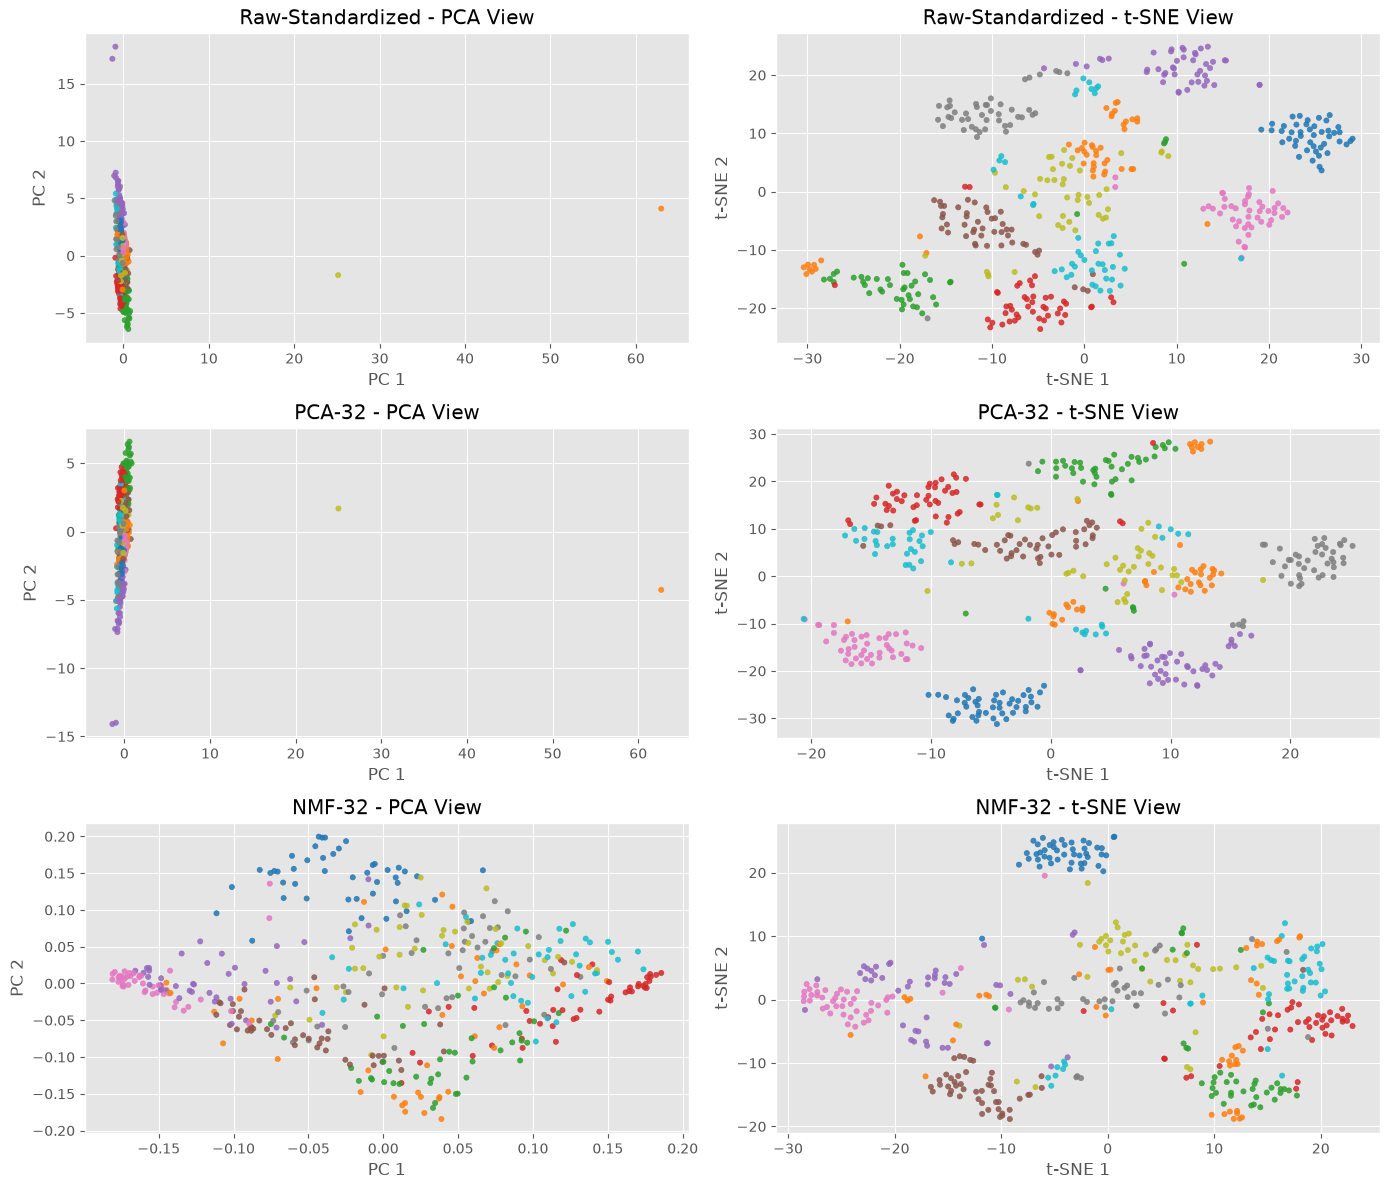

In [9]:
# Execute side-by-side PCA and t-SNE visual comparisons
visualize_embeddings_with_pca_and_tsne(
    embedding_spaces=embedding_spaces, labels=y_test, sample_size=500
)

When interpreting these plots, look for:

- Compact, well-separated clusters (often associated with stronger retrieval quality).
- Excessive overlap (can indicate weaker neighborhood structure for similarity search).
- Stability between PCA and t-SNE views (a sign that structure is not purely a projection artifact).


## Student Tasks

Apply what you learned by modifying retrieval settings and embedding dimensions.


<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1> Question #1: </h1>
<b>Evaluate the PCA-32 embedding with top_k=3 instead of top_k=5, then compare both metrics and explain the trade-off.</b>
</div>


In [10]:
# TODO 1: Evaluate PCA-32 using top_k=3.
# TODO 2: Compare Hit@3 and MRR against the existing Hit@5 result.
# TODO 3: Write one sentence about precision-vs-recall behavior in ranked retrieval.

# Select the PCA embedding vectors from the benchmark dictionary
pca_train_vectors = embedding_spaces["PCA-32"]["train"]
pca_test_vectors = embedding_spaces["PCA-32"]["test"]

# Compute metrics at top_k=3 for a stricter retrieval window
pca_top3_metrics = evaluate_retrieval(
    train_vectors=pca_train_vectors,
    train_labels=y_train,
    test_vectors=pca_test_vectors,
    test_labels=y_test,
    top_k=3,
)

# Compute metrics at top_k=5 for direct side-by-side comparison
pca_top5_metrics = evaluate_retrieval(
    train_vectors=pca_train_vectors,
    train_labels=y_train,
    test_vectors=pca_test_vectors,
    test_labels=y_test,
    top_k=5,
)

# Print both result sets with clear labels
print("PCA-32 @ top_k=3:", pca_top3_metrics)
print("PCA-32 @ top_k=5:", pca_top5_metrics)

# Typical interpretation: top_k=3 is stricter and may reduce Hit@K while preserving strong MRR

PCA-32 @ top_k=3: {'Hit@K': 0.9755555555555555, 'MRR': 0.9674074074074075}
PCA-32 @ top_k=5: {'Hit@K': 0.98, 'MRR': 0.9682962962962963}


<details><summary>Click here for the solution</summary>

```python
# Select the PCA embedding vectors from the benchmark dictionary
pca_train_vectors = embedding_spaces["PCA-32"]["train"]
pca_test_vectors = embedding_spaces["PCA-32"]["test"]

# Compute metrics at top_k=3 for a stricter retrieval window
pca_top3_metrics = evaluate_retrieval(
    train_vectors=pca_train_vectors,
    train_labels=y_train,
    test_vectors=pca_test_vectors,
    test_labels=y_test,
    top_k=3
)

# Compute metrics at top_k=5 for direct side-by-side comparison
pca_top5_metrics = evaluate_retrieval(
    train_vectors=pca_train_vectors,
    train_labels=y_train,
    test_vectors=pca_test_vectors,
    test_labels=y_test,
    top_k=5
)

# Print both result sets with clear labels
print("PCA-32 @ top_k=3:", pca_top3_metrics)
print("PCA-32 @ top_k=5:", pca_top5_metrics)

# Typical interpretation: top_k=3 is stricter and may reduce Hit@K while preserving strong MRR
```

</details>


<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1> Question #2: </h1>
<b>Rebuild embeddings with 16 dimensions, rerun retrieval comparison, and decide whether lower memory usage justifies any quality loss.</b>
</div>


In [11]:
# TODO 1: Rebuild embedding spaces with n_components=16.
# TODO 2: Recompute Hit@5 and MRR for all models.
# TODO 3: Compare 16-dimensional results against the 32-dimensional benchmark table.

# Rebuild embedding spaces with a lower latent dimension
embedding_spaces_16 = build_embedding_spaces(
    X_train_raw=X_train, X_test_raw=X_test, n_components=16
)

# Evaluate each model at top_k=5 to match the main benchmark setup
comparison_rows_16 = []
for model_name, vectors in embedding_spaces_16.items():
    metrics = evaluate_retrieval(
        train_vectors=vectors["train"],
        train_labels=y_train,
        test_vectors=vectors["test"],
        test_labels=y_test,
        top_k=5,
    )

    # Save comparable outputs for side-by-side decision making
    comparison_rows_16.append(
        {
            "Model": model_name.replace("32", "16"),
            "Hit@5": round(metrics["Hit@K"], 4),
            "MRR": round(metrics["MRR"], 4),
            "Embedding Dimension": vectors["train"].shape[1],
        }
    )

# Display and compare with the original results_df from n_components=32
results_df_16 = (
    pd.DataFrame(comparison_rows_16)
    .sort_values(by=["MRR", "Hit@5"], ascending=False)
    .reset_index(drop=True)
)

print("Results with 16 dimensions:")
display(results_df_16)

print("Results with 32 dimensions (baseline):")
display(results_df)

Results with 16 dimensions:


,Model,Hit@5,MRR,Embedding Dimension
0,Raw-Standardized,0.9822,0.9702,64
1,PCA-16,0.9756,0.9587,16
2,NMF-16,0.9756,0.9483,16


Results with 32 dimensions (baseline):


,Model,Hit@5,MRR,Embedding Dimension
0,Raw-Standardized,0.9822,0.9702,64
1,PCA-32,0.9800,0.9683,32
2,NMF-32,0.9778,0.9432,32


<details><summary>Click here for the solution</summary>

```python
# Rebuild embedding spaces with a lower latent dimension
embedding_spaces_16 = build_embedding_spaces(
    X_train_raw=X_train,
    X_test_raw=X_test,
    n_components=16
)

# Evaluate each model at top_k=5 to match the main benchmark setup
comparison_rows_16 = []
for model_name, vectors in embedding_spaces_16.items():
    metrics = evaluate_retrieval(
        train_vectors=vectors["train"],
        train_labels=y_train,
        test_vectors=vectors["test"],
        test_labels=y_test,
        top_k=5
    )

    # Save comparable outputs for side-by-side decision making
    comparison_rows_16.append(
        {
            "Model": model_name.replace("32", "16"),
            "Hit@5": round(metrics["Hit@K"], 4),
            "MRR": round(metrics["MRR"], 4),
            "Embedding Dimension": vectors["train"].shape[1]
        }
    )

# Display and compare with the original results_df from n_components=32
results_df_16 = pd.DataFrame(comparison_rows_16).sort_values(
    by=["MRR", "Hit@5"],
    ascending=False
).reset_index(drop=True)

print("Results with 16 dimensions:")
display(results_df_16)

print("Results with 32 dimensions (baseline):")
display(results_df)
```

</details>


## Conclusion

You built a full embedding comparison workflow with governed data intake, retrieval metrics, and geometric diagnostics. This is the same evidence pattern used in enterprise model selection meetings: quality metrics + operational trade-offs + visual sanity checks.

Recommended model selection pattern:

- Start with the highest MRR candidate.
- Validate visualization quality for class separation.
- Apply latency and memory constraints to finalize deployment choice.


## Author

<a href="https://author.skills.network/instructors/dmytro_shliakhovskyi">Dmytro Shliakhovskyi</a>

## Change Log
| Date (YYYY-MM-DD) | Version | Changed By | Change Description |
| ----------------- | ------- | ---------- | ------------------ |
| 2026-04-10 | 01 | Dmytro Shliakhovskyi | Lab created |

<h3 align="center"> © IBM Corporation 2020. All rights reserved. <h3/>
